# Train ReliFuse with user-selected experts

Use this path when you already know which expert models should be fused. `K` is the number of loaded expert checkpoints. No selector runs, so `requested_experts` must match the number of supplied models.


In [1]:
import sys
import tempfile
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
sys.path.insert(0, str(ROOT))

import torch

from examples.loaded_expert_demo import (
    create_demo_checkpoints,
    load_expert_models,
    make_synthetic_vessel_split,
    plot_fusion_case,
    predict_stack,
)
from relifuse import ReliFuse, TrainingConfig, expert_dice_scores, fit, seed_everything

seed_everything(7)

from relifuse import use_all_experts


In [2]:
# Demo data: license-clean synthetic vessel masks.
# Replace this cell with your real Dataset/DataLoader. Keep outputs as [B,1,H,W].
train_images, train_masks = make_synthetic_vessel_split(10, seed=10)
validation_images, validation_masks = make_synthetic_vessel_split(5, seed=20)
test_images, test_masks = make_synthetic_vessel_split(3, seed=30)

print(train_images.shape, validation_images.shape, test_images.shape)


torch.Size([10, 1, 48, 48]) torch.Size([5, 1, 48, 48]) torch.Size([3, 1, 48, 48])


In [3]:
# Demo only: train tiny experts and write their weights to a temp directory.
# In real use, replace checkpoint_paths with your own model weight files.
tmp = tempfile.TemporaryDirectory()
expert_specs = [
    ("tiny_cnn_a", "cnn", 6, 1),
    ("tiny_cnn_b", "cnn", 8, 2),
    ("tiny_context", "context", 10, 1),
]
checkpoints = create_demo_checkpoints(tmp.name, train_images, train_masks, expert_specs)
models = load_expert_models(checkpoints)
names = [checkpoint.name for checkpoint in checkpoints]
families = [checkpoint.family for checkpoint in checkpoints]

print(names)
print([str(checkpoint.path) for checkpoint in checkpoints])


['tiny_cnn_a', 'tiny_cnn_b', 'tiny_context']
['/var/folders/bm/6xws8v017wj6kvp96xcm_rkdfhvql5/T/tmpu0rpkfua/tiny_cnn_a.pt', '/var/folders/bm/6xws8v017wj6kvp96xcm_rkdfhvql5/T/tmpu0rpkfua/tiny_cnn_b.pt', '/var/folders/bm/6xws8v017wj6kvp96xcm_rkdfhvql5/T/tmpu0rpkfua/tiny_context.pt']


In [4]:
# Convert loaded model predictions into ReliFuse posterior stacks: [B,K,H,W].
train_predictions = predict_stack(models, train_images)
validation_predictions = predict_stack(models, validation_images)
test_predictions = predict_stack(models, test_images)

bank = use_all_experts(
    train_predictions,
    names=names,
    families=families,
    requested_experts=len(models),
)
print(bank)


ExpertBank(selected_indices=(0, 1, 2), selected_names=('tiny_cnn_a', 'tiny_cnn_b', 'tiny_context'), families=('cnn', 'cnn', 'context'))


In [5]:
quality = expert_dice_scores(validation_predictions, validation_masks)
fusion = ReliFuse(num_experts=bank.num_experts, expert_scores=quality)

history = fit(
    fusion,
    train_predictions,
    train_masks,
    validation_predictions,
    validation_masks,
    config=TrainingConfig(epochs=3, batch_size=2, patience=3),
)
print(history.to_dict())


{'records': [{'epoch': 1, 'train_loss': 0.24726863205432892, 'train_dice': 0.9343379020690918, 'validation_loss': 0.22816528379917145, 'validation_dice': 0.94602503379186, 'learning_rate': 0.001}, {'epoch': 2, 'train_loss': 0.2204922616481781, 'train_dice': 0.9379873156547547, 'validation_loss': 0.1999295304218928, 'validation_dice': 0.9510058164596558, 'learning_rate': 0.0007625}, {'epoch': 3, 'train_loss': 0.1987796038389206, 'train_dice': 0.9418255925178528, 'validation_loss': 0.18868895868460336, 'validation_dice': 0.951916515827179, 'learning_rate': 0.0002875000000000001}], 'best_epoch': 3, 'best_validation_loss': 0.18868895868460336, 'best_validation_dice': 0.951916515827179}


torch.Size([3, 1, 48, 48]) torch.Size([3, 1, 48, 48])


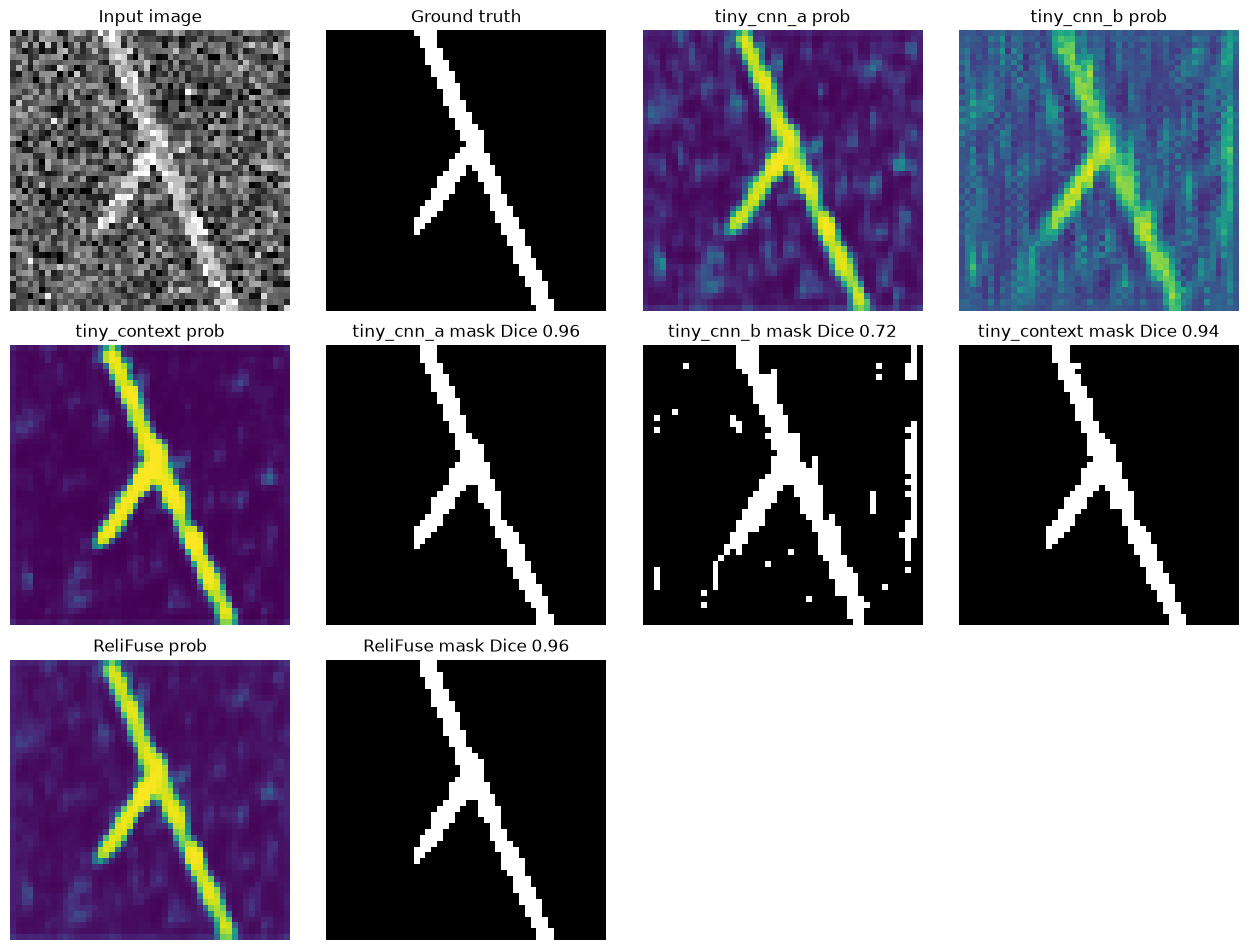

In [6]:
with torch.inference_mode():
    fused_probability = fusion.fuse(test_predictions)
    fused_mask = fusion.fuse(test_predictions, threshold=0.5)

print(fused_probability.shape, fused_mask.shape)
plot_fusion_case(
    test_images[0],
    test_masks[0],
    test_predictions[0],
    fused_probability[0],
    expert_names=bank.selected_names,
)
tmp.cleanup()
